<a href="https://colab.research.google.com/github/siddikha1234/ELiteTEch-Intern/blob/main/task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4497 - loss: 1.5141 - val_accuracy: 0.5476 - val_loss: 1.2485
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5936 - loss: 1.1482 - val_accuracy: 0.6157 - val_loss: 1.0970
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.6430 - loss: 1.0094 - val_accuracy: 0.6360 - val_loss: 1.0282
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.6822 - loss: 0.9068 - val_accuracy: 0.6666 - val_loss: 0.9696
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7062 - loss: 0.8400 - val_accuracy: 0.6745 - val_loss: 0.9237
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7287 - loss: 0.7797 - val_accuracy: 0.6948 - val_loss: 0.8928
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.7445 - loss: 0.7269 - val_accuracy: 0.7035 - val_loss: 0.8810
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7608 -

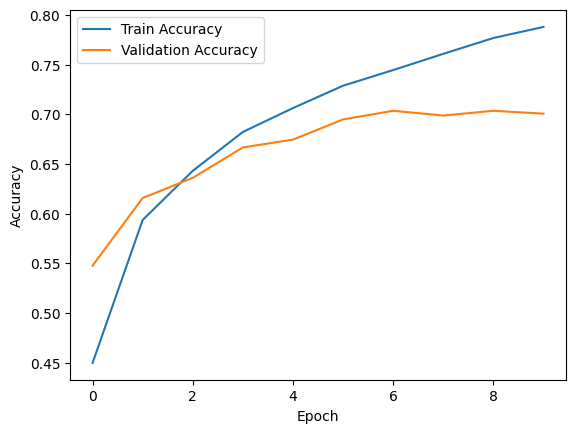

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


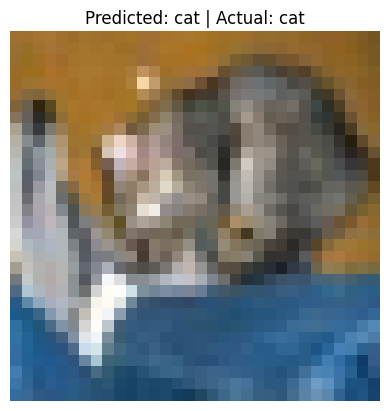

Model saved successfully!


In [2]:
# ============================================
# IMAGE CLASSIFICATION USING CNN (TENSORFLOW)
# ============================================

# Step 1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Step 2: Load Dataset (CIFAR-10)
# ============================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# ============================================
# Step 3: Define Class Names
# ============================================
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# ============================================
# Step 4: Build CNN Model
# ============================================
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu',
                         input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

# ============================================
# Step 5: Compile Model
# ============================================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ============================================
# Step 6: Train Model
# ============================================
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# ============================================
# Step 7: Evaluate Model
# ============================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

# ============================================
# Step 8: Plot Accuracy Graph
# ============================================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ============================================
# Step 9: Predictions Example
# ============================================
predictions = model.predict(x_test)

def show_prediction(index):
    plt.imshow(x_test[index])
    plt.title("Predicted: {} | Actual: {}".format(
        class_names[np.argmax(predictions[index])],
        class_names[y_test[index][0]]
    ))
    plt.axis('off')
    plt.show()

# Show sample prediction
show_prediction(0)

# ============================================
# Step 10: Save Model
# ============================================
model.save("cnn_image_classifier.h5")
print("Model saved successfully!")